In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [2]:
MASTER = "/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb/master_feature_engineered.parquet"

master = pd.read_parquet(MASTER)

print(master.shape)

(35072, 122)


In [3]:
MODEL_PATH = "/kaggle/input/huggingface-models/sentence-transformers/all-MiniLM-L6-v2"

try:
    model = SentenceTransformer(MODEL_PATH)
except:
    model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")


unique_objectives = (
    master["learning_objective"]
    .fillna("")
    .unique()
)

objective_embeddings = model.encode(
    unique_objectives,
    batch_size=64,
    normalize_embeddings=True,
    show_progress_bar=True,
)

pca = PCA(
    n_components=32,
    random_state=42,
)

objective_embeddings = pca.fit_transform(objective_embeddings)

embedding_map = {
    obj: emb
    for obj, emb in zip(unique_objectives, objective_embeddings)
}

objective_matrix = np.vstack(
    master["learning_objective"]
    .fillna("")
    .map(embedding_map)
)

objective_df = pd.DataFrame(
    objective_matrix,
    columns=[
        f"obj_emb_{i}"
        for i in range(objective_matrix.shape[1])
    ]
)

master = pd.concat(
    [
        master.reset_index(drop=True),
        objective_df.reset_index(drop=True)
    ],
    axis=1,
)

print(master.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

(35072, 154)


In [4]:
TARGET = "is_correct"

DROP_COLUMNS = [

    "response_id",
    "session_id",

    "learning_objective",
    "learning_objective_id",

    "transcript",
    "student_text",
    "tutor_text",
    "background_text",

    TARGET,
]

X = master.drop(columns=DROP_COLUMNS)

y = master[TARGET].astype(int)

print(X.shape)

(35072, 145)


In [5]:
cat_cols = X.select_dtypes(include="object").columns

for col in cat_cols:
    X[col] = X[col].astype("category").cat.codes

print(cat_cols.tolist())

['objective_family']


In [6]:
BEST_PARAMS = {

    "objective": "binary:logistic",

    "eval_metric": "logloss",

    "learning_rate": 0.02,

    "max_depth": 7,

    "min_child_weight": 1,

    "subsample": 0.8,

    "colsample_bytree": 0.6,

    "n_estimators": 5000,

    "random_state": 42,

    "tree_method": "hist",

    "early_stopping_rounds": 300,
}

In [7]:
kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

oof_pred = np.zeros(len(X))

scores = []

importance = pd.DataFrame()

for fold, (train_idx, valid_idx) in enumerate(kf.split(X, y), 1):

    print("=" * 60)
    print(f"Fold {fold}")
    print("=" * 60)

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_valid = X.iloc[valid_idx]
    y_valid = y.iloc[valid_idx]

    model = XGBClassifier(**BEST_PARAMS)

    model.fit(

        X_train,
        y_train,

        eval_set=[(X_valid, y_valid)],

        verbose=False,
    )

    pred = model.predict_proba(X_valid)[:, 1]

    oof_pred[valid_idx] = pred

    loss = log_loss(y_valid, pred)

    scores.append(loss)

    print(f"Fold LogLoss : {loss:.6f}")

    fold_importance = pd.DataFrame({

        "feature": X.columns,

        "importance": model.feature_importances_

    })

    importance = pd.concat(
        [
            importance,
            fold_importance
        ]
    )

Fold 1
Fold LogLoss : 0.535718
Fold 2
Fold LogLoss : 0.543593
Fold 3
Fold LogLoss : 0.541257
Fold 4
Fold LogLoss : 0.540556
Fold 5
Fold LogLoss : 0.542212


In [8]:
overall = log_loss(y, oof_pred)

print()

print("=" * 60)

print("Fold LogLoss")

print(scores)

print()

print("Mean LogLoss :", np.mean(scores))

print("Std LogLoss  :", np.std(scores))

print("=" * 60)

print()

print("=" * 60)

print(f"Overall OOF LogLoss : {overall:.6f}")

print("=" * 60)


Fold LogLoss
[0.5357180759652302, 0.5435929913460982, 0.5412566109633764, 0.5405561720434789, 0.542211746928326]

Mean LogLoss : 0.5406671194493019
Std LogLoss  : 0.0026757967555356395

Overall OOF LogLoss : 0.540667


,feature,importance
0,obj_has_money,0.024838
1,obj_emb_29,0.015943
2,obj_emb_16,0.015666
3,obj_emb_24,0.014390
4,objective_char_count,0.014206
5,obj_emb_1,0.013772
6,obj_emb_7,0.012948
7,obj_emb_10,0.011642
8,objective_frequency,0.011076
9,obj_emb_6,0.011069


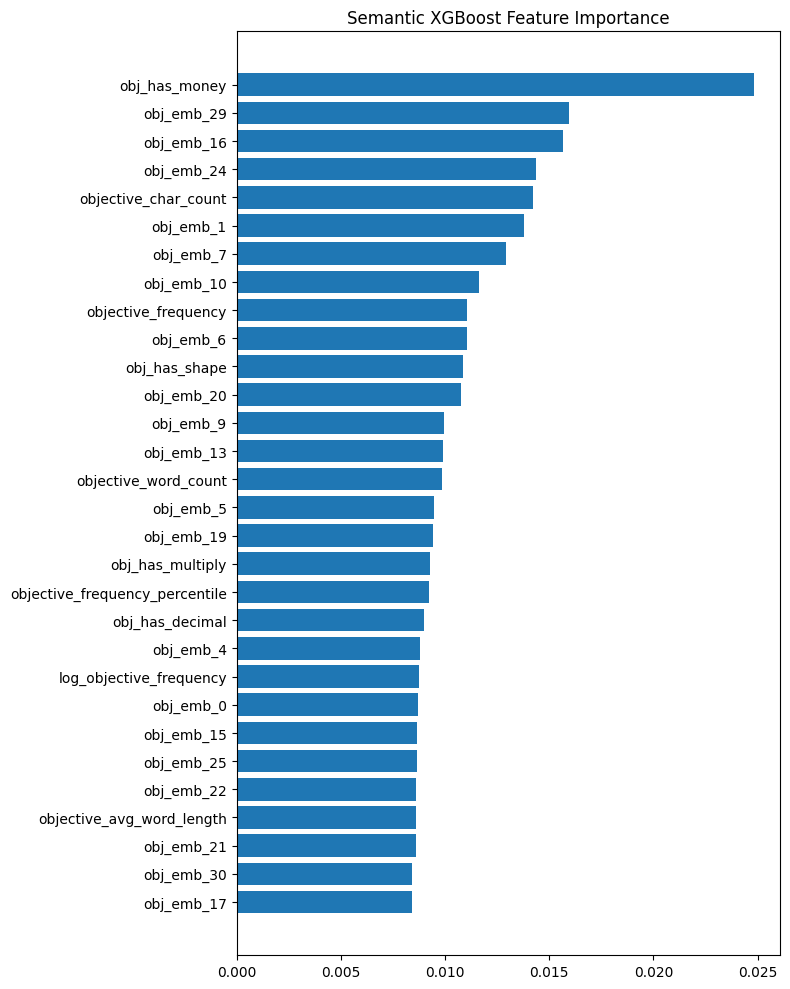

In [9]:
importance = (
    importance
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

display(importance.head(30))

plt.figure(figsize=(8,10))

plt.barh(

    importance.head(30)["feature"][::-1],

    importance.head(30)["importance"][::-1],

)

plt.title("Semantic XGBoost Feature Importance")

plt.tight_layout()

plt.show()